In [25]:
from qdrant_client import QdrantClient
from qdrant_client.models import PointStruct, VectorParams, Distance
import uuid

client = QdrantClient(host="localhost", port=6333)
COLLECTION_LFW = "face_lfw"

# Crea la collection solo se non esiste già
existing = client.get_collections().collections
if COLLECTION_LFW not in [c.name for c in existing]:
    client.create_collection(
        collection_name=COLLECTION_LFW,
        vectors_config=VectorParams(size=512, distance=Distance.COSINE)
    )

In [ ]:
from sklearn.datasets import fetch_lfw_people

lfw = fetch_lfw_people(min_faces_per_person=10, resize=1.0, color=True)

print("people:", len(lfw.target_names))
print("total pictures:", lfw.images.shape)
print("picture shape:", lfw.images.shape[1], "x", lfw.images.shape[2])
print("\first 10 people:")
for i, name in enumerate(lfw.target_names[:10]):
    count = (lfw.target == i).sum()
    print(f"  {name}: {count} photos")


people: 158
total pictures: (4324, 125, 94, 3)
picture shape: 125 x 94
irst 10 people:
  Abdullah Gul: 19 foto
  Adrien Brody: 12 foto
  Alejandro Toledo: 39 foto
  Alvaro Uribe: 35 foto
  Amelie Mauresmo: 21 foto
  Andre Agassi: 36 foto
  Andy Roddick: 15 foto
  Angelina Jolie: 20 foto
  Ann Veneman: 11 foto
  Anna Kournikova: 12 foto


In [15]:
import cv2
import numpy as np

def numpy_to_bytes(img_array):
    # LFW dà float32 tra 0 e 255, va convertito in uint8
    img_uint8 = (img_array*255).astype(np.uint8)
    # converti RGB -> BGR per OpenCV
    img_bgr = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2BGR)
    # encode in JPEG bytes
    _, buffer = cv2.imencode('.jpg', img_bgr)
    return buffer.tobytes()

In [16]:
img_bytes = numpy_to_bytes(lfw.images[0])
print("Bytes created:", len(img_bytes))

Bytes created: 5613


In [20]:
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

MODEL_PATH = "model/blaze_face_short_range.tflite" 

base_options = python.BaseOptions(model_asset_path=MODEL_PATH)
options = vision.FaceDetectorOptions(base_options=base_options)
detector = vision.FaceDetector.create_from_options(options)

In [21]:

from detecVisage import FacesDetects_from_bytes
from faceAlignment import align_crop
from embeddings import get_embedding

img_bytes = numpy_to_bytes(lfw.images[7])
boxes, detection_result, image = FacesDetects_from_bytes(img_bytes, "mediapipe", detector)
print("Volti rilevati:", len(boxes))

Volti rilevati: 1


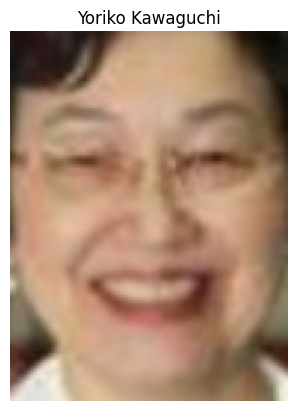

In [18]:
import matplotlib.pyplot as plt

plt.imshow(lfw.images[7])
plt.title(lfw.target_names[lfw.target[7]])
plt.axis('off')
plt.show()

In [22]:
from collections import defaultdict
import numpy as np

# Raggruppa gli indici per persona
person_indices = defaultdict(list)
for idx, label in enumerate(lfw.target):
    person_indices[label].append(idx)

# Split 80/20 per ogni persona
db_indices = []
eval_indices = []

for label, indices in person_indices.items():
    n = len(indices)
    n_db = max(1, int(n * 0.8))  # almeno 1 foto nel DB
    db_indices.extend(indices[:n_db])
    eval_indices.extend(indices[n_db:])

print(f"Foto nel DB: {len(db_indices)}")
print(f"Foto evaluation: {len(eval_indices)}")

Foto nel DB: 3397
Foto evaluation: 927


In [23]:
from tqdm.notebook import tqdm

test_labels = list(person_indices.keys())[:10]

for label in tqdm(test_labels):
    indices = person_indices[label]
    n_db = max(1, int(len(indices) * 0.8))
    
    for idx in indices[:n_db]:
        img_bytes = numpy_to_bytes(lfw.images[idx])
        boxes, detection_result, image = FacesDetects_from_bytes(img_bytes, "mediapipe", detector)
        
        if not detection_result or not detection_result.detections:
            continue
        
        crops = align_crop(image, detection_result)
        if not crops:
            continue
        
        embedding = get_embedding(crops[0])
        
        # salva in face_lfw
        client.upsert(
            collection_name=COLLECTION_LFW,
            points=[PointStruct(
                id=str(uuid.uuid4()),
                vector=embedding.tolist(),
                payload={"name": lfw.target_names[label]}
            )]
        )

print("Done!")

# verifica
count = client.count(collection_name=COLLECTION_LFW)
print(f"Vettori nel DB: {count.count}")

  0%|          | 0/10 [00:00<?, ?it/s]

Done!
Vettori nel DB: 392


In [26]:
for label in tqdm(list(person_indices.keys())):
    indices = person_indices[label]
    n_db = max(1, int(len(indices) * 0.8))
    
    for idx in indices[:n_db]:
        img_bytes = numpy_to_bytes(lfw.images[idx])
        boxes, detection_result, image = FacesDetects_from_bytes(img_bytes, "mediapipe", detector)
        
        if not detection_result or not detection_result.detections:
            continue
        
        crops = align_crop(image, detection_result)
        if not crops:
            continue
        
        embedding = get_embedding(crops[0])
        
        client.upsert(
            collection_name=COLLECTION_LFW,
            points=[PointStruct(
                id=str(uuid.uuid4()),
                vector=embedding.tolist(),
                payload={"name": lfw.target_names[label]}
            )]
        )

  0%|          | 0/158 [00:00<?, ?it/s]

In [27]:
count = client.count(collection_name=COLLECTION_LFW)
print(f"Vettori nel DB: {count.count}")

Vettori nel DB: 3381


In [28]:
results_lfw = []
detection_failures_lfw = 0

for label in tqdm(list(person_indices.keys())):
    indices = person_indices[label]
    n_db = max(1, int(len(indices) * 0.8))
    eval_idxs = indices[n_db:]  # solo il 20%
    
    for idx in eval_idxs:
        img_bytes = numpy_to_bytes(lfw.images[idx])
        boxes, detection_result, image = FacesDetects_from_bytes(img_bytes, "mediapipe", detector)
        
        if not detection_result or not detection_result.detections:
            detection_failures_lfw += 1
            continue
        
        crops = align_crop(image, detection_result)
        if not crops:
            detection_failures_lfw += 1
            continue
        
        embedding = get_embedding(crops[0])
        
        raw = client.query_points(
            collection_name=COLLECTION_LFW,
            query=embedding.tolist(),
            limit=1
        ).points
        
        if not raw:
            score, predicted_name = 0.0, "unknown"
        else:
            score = raw[0].score
            predicted_name = raw[0].payload["name"]
        
        results_lfw.append({
            "label_true": lfw.target_names[label],
            "predicted_name": predicted_name,
            "score": score,
            "is_genuine": True
        })

print(f"Genuine attempts: {len(results_lfw)}")
print(f"Detection failures: {detection_failures_lfw}")

  0%|          | 0/158 [00:00<?, ?it/s]

Genuine attempts: 921
Detection failures: 6


In [29]:
from sklearn.datasets import fetch_lfw_people

lfw_all = fetch_lfw_people(min_faces_per_person=1, resize=1.0, color=True)

# Persone già nel DB
registered_names = set(lfw.target_names)

# Persone NON nel DB → impostors
impostor_indices = [
    i for i, label in enumerate(lfw_all.target)
    if lfw_all.target_names[label] not in registered_names
]

print(f"Foto impostors disponibili: {len(impostor_indices)}")

Foto impostors disponibili: 8909


In [31]:
import random
random.seed(42)
impostor_sample = random.sample(impostor_indices, 300)
print(f"Impostors selezionati: {len(impostor_sample)}")

Impostors selezionati: 300


In [32]:
for idx in tqdm(impostor_sample):
    img_bytes = numpy_to_bytes(lfw_all.images[idx])
    boxes, detection_result, image = FacesDetects_from_bytes(img_bytes, "mediapipe", detector)
    
    if not detection_result or not detection_result.detections:
        detection_failures_lfw += 1
        continue
    
    crops = align_crop(image, detection_result)
    if not crops:
        detection_failures_lfw += 1
        continue
    
    embedding = get_embedding(crops[0])
    
    raw = client.query_points(
        collection_name=COLLECTION_LFW,
        query=embedding.tolist(),
        limit=1
    ).points
    
    score = raw[0].score if raw else 0.0
    predicted_name = raw[0].payload["name"] if raw else "unknown"
    
    results_lfw.append({
        "label_true": "unknown",
        "predicted_name": predicted_name,
        "score": score,
        "is_genuine": False
    })

genuine_lfw = [r for r in results_lfw if r["is_genuine"]]
impostor_lfw = [r for r in results_lfw if not r["is_genuine"]]

print(f"Genuine: {len(genuine_lfw)}")
print(f"Impostors: {len(impostor_lfw)}")

  0%|          | 0/300 [00:00<?, ?it/s]

Genuine: 921
Impostors: 299


In [34]:
THRESHOLD = np.arange(0.0, 1.01, 0.01)
from sklearn.metrics import auc
def tar_lfw(t):
    return sum(1 for r in genuine_lfw if r["score"] >= t and r["predicted_name"] == r["label_true"]) / len(genuine_lfw)

def far_lfw(t):
    return sum(1 for r in impostor_lfw if r["score"] >= t) / len(impostor_lfw)

def frr_lfw(t):
    return sum(1 for r in genuine_lfw if r["score"] < t or r["predicted_name"] != r["label_true"]) / len(genuine_lfw)

tar_list = np.array([tar_lfw(t) for t in THRESHOLD])
far_list = np.array([far_lfw(t) for t in THRESHOLD])
frr_list = np.array([frr_lfw(t) for t in THRESHOLD])

# EER
eer_idx = np.argmin(np.abs(far_list - frr_list))
eer_value = (far_list[eer_idx] + frr_list[eer_idx]) / 2
eer_threshold = THRESHOLD[eer_idx]

print(f"EER        : {eer_value*100:.2f}%")
print(f"Seuil EER  : {eer_threshold:.2f}")
print(f"TAR at EER : {tar_list[eer_idx]*100:.2f}%")
print(f"AUC (ROC)  : {auc(far_list, tar_list):.4f}")


EER        : 7.42%
Seuil EER  : 0.54
TAR at EER : 91.86%
AUC (ROC)  : 0.9500


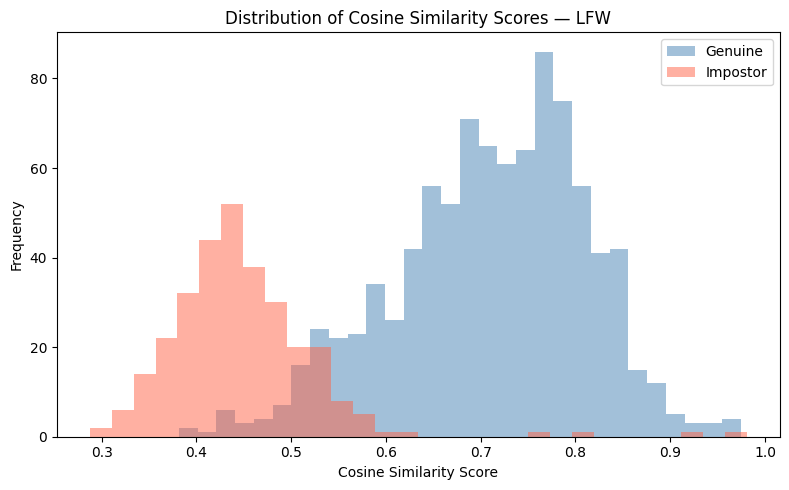

In [35]:
plt.figure(figsize=(8, 5))
plt.hist([r["score"] for r in genuine_lfw], bins=30, alpha=0.5, label="Genuine", color="steelblue")
plt.hist([r["score"] for r in impostor_lfw], bins=30, alpha=0.5, label="Impostor", color="tomato")
plt.xlabel("Cosine Similarity Score")
plt.ylabel("Frequency")
plt.title("Distribution of Cosine Similarity Scores — LFW")
plt.legend()
plt.tight_layout()
plt.show()


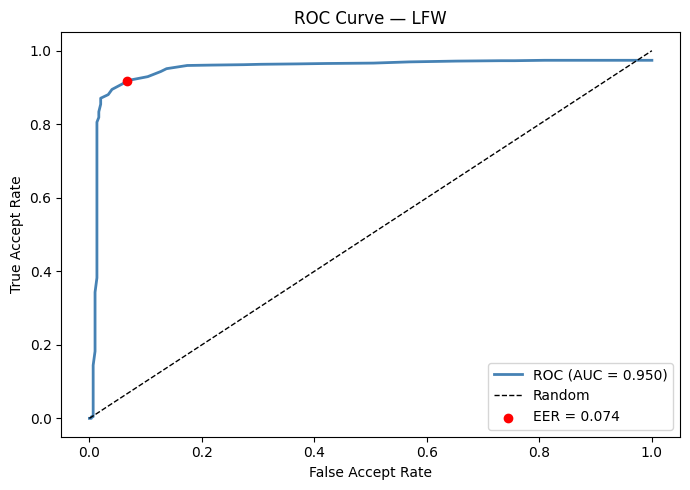

In [36]:
plt.figure(figsize=(7, 5))
plt.plot(far_list, tar_list, color="steelblue", lw=2, label=f"ROC (AUC = {auc(far_list, tar_list):.3f})")
plt.plot([0, 1], [0, 1], "k--", lw=1, label="Random")
plt.scatter(far_list[eer_idx], tar_list[eer_idx], color="red", zorder=5, label=f"EER = {eer_value:.3f}")
plt.xlabel("False Accept Rate")
plt.ylabel("True Accept Rate")
plt.title("ROC Curve — LFW")
plt.legend()
plt.tight_layout()
plt.show()

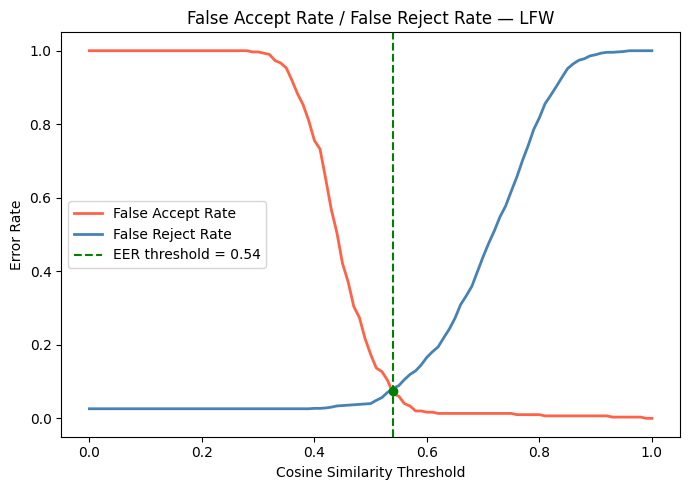

In [37]:
plt.figure(figsize=(7, 5))
plt.plot(THRESHOLD, far_list, color="tomato", lw=2, label="False Accept Rate")
plt.plot(THRESHOLD, frr_list, color="steelblue", lw=2, label="False Reject Rate")
plt.axvline(eer_threshold, color="green", linestyle="--", lw=1.5, label=f"EER threshold = {eer_threshold:.2f}")
plt.scatter(eer_threshold, eer_value, color="green", zorder=5)
plt.xlabel("Cosine Similarity Threshold")
plt.ylabel("Error Rate")
plt.title("False Accept Rate / False Reject Rate — LFW")
plt.legend()
plt.tight_layout()
plt.show()
